[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch09.ipynb)

Notebook Bab 9 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Kualitas fitur diukur dari kontribusinya ke performa. Kita pakai *ablation* per kelompok dan *permutation importance* untuk menilai kelompok fitur mana yang penting.

## Persiapan

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
print('Setup selesai.')

Setup selesai.


# Section 1 - Demo: Ablation dan Permutation Importance per Kelompok

## Data: tiga kelompok fitur

Kelompok `transaksi` membawa sinyal kuat, `interaksi` lemah, dan `demografis` tanpa sinyal.

In [2]:
n = 3000
demografis = rng.normal(size=(n, 5))
transaksi = rng.normal(size=(n, 5))
interaksi = rng.normal(size=(n, 5))
logit = transaksi @ np.array([1.5, 1.2, -1.0, 0.8, -0.6]) + interaksi @ np.array([0.4, -0.3, 0.3, 0.0, 0.0])
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
X = np.hstack([demografis, transaksi, interaksi])
grup = {'demografis': list(range(0, 5)), 'transaksi': list(range(5, 10)), 'interaksi': list(range(10, 15))}
print('Data:', X.shape, '| kelompok:', list(grup.keys()))

Data: (3000, 15) | kelompok: ['demografis', 'transaksi', 'interaksi']


## Ablation: hapus satu kelompok, ukur penurunan akurasi

In [3]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

def acc_with(cols):
    m = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xtr[:, cols], ytr)
    return accuracy_score(yte, m.predict(Xte[:, cols]))

semua = list(range(15))
base = acc_with(semua)
print(f'Baseline (semua kelompok) = {base:.3f}')
for nama, idx in grup.items():
    sisa = [c for c in semua if c not in idx]
    a = acc_with(sisa)
    print(f'Tanpa {nama:11s}: akurasi = {a:.3f}  (turun {base - a:+.3f})')

Baseline (semua kelompok) = 0.798


Tanpa demografis : akurasi = 0.809  (turun -0.011)


Tanpa transaksi  : akurasi = 0.531  (turun +0.267)


Tanpa interaksi  : akurasi = 0.789  (turun +0.009)


## Permutation importance, dijumlahkan per kelompok

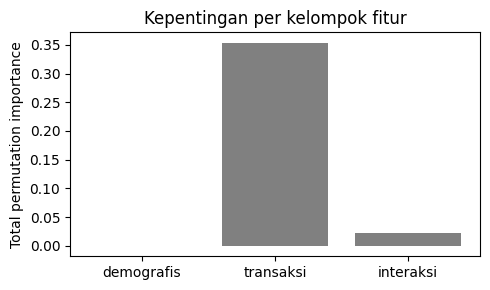

{'demografis': -0.0006666666666665043, 'transaksi': 0.3540000000000002, 'interaksi': 0.02266666666666681}


In [4]:
m = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xtr, ytr)
imp = permutation_importance(m, Xte, yte, n_repeats=10, random_state=RANDOM_STATE)
grup_imp = {nama: float(imp.importances_mean[idx].sum()) for nama, idx in grup.items()}

plt.figure(figsize=(5, 3))
plt.bar(list(grup_imp.keys()), list(grup_imp.values()), color='0.5')
plt.ylabel('Total permutation importance')
plt.title('Kepentingan per kelompok fitur')
plt.tight_layout(); plt.show()
print(grup_imp)

> 🔎 **Amati.** Kedua metode sepakat: menghapus kelompok `transaksi` menurunkan akurasi paling jauh dan kelompok itu juga memuncaki *permutation importance*, sedangkan `demografis` nyaris tidak berpengaruh. *Ablation* mengukur kontribusi satu kelompok terhadap performa; *permutation importance* mengukur seberapa besar model bergantung pada fitur tersebut.

# Section 2 - Mini Project

## Soal

Anda diberi data dengan dua kelompok fitur (`sinyal` dan `noise`). Targetnya klasifikasi biner.

Tugas:

1. Tetapkan *baseline* dengan semua fitur.
2. Lakukan *ablation* per kelompok dan laporkan penurunan akurasi.
3. Bandingkan hasil *ablation* dengan *permutation importance*.

**Luaran:** kode *ablation* + *permutation importance*, plus 2-3 kalimat kesimpulan kelompok mana yang penting.

**Kriteria penilaian:** (a) *baseline* jelas; (b) *ablation* per kelompok benar; (c) kesimpulan konsisten antar-metode.

In [5]:
# DATA AWAL (jangan diubah) - dua kelompok: sinyal (kuat) dan noise (kosong).
n = 2500
sinyal = rng.normal(size=(n, 6))
noise = rng.normal(size=(n, 6))
logit = sinyal @ np.array([1.4, -1.1, 0.9, -0.7, 0.5, -0.4])
yq = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
Xq = np.hstack([sinyal, noise])
grup_q = {'sinyal': list(range(0, 6)), 'noise': list(range(6, 12))}
print('Data:', Xq.shape, '| kelompok:', list(grup_q.keys()))

Data: (2500, 12) | kelompok: ['sinyal', 'noise']


In [6]:
# Kerjakan di sini.
# Petunjuk: latih model pada subset kolom untuk ablation; sklearn.inspection.permutation_importance untuk pembanding.
